In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.kernel_ridge import KernelRidge
import tensorflow as tf
'''from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense'''


''' 
pour chaque méthodes:
- présentation de la méthode 
- présentation des hyperparamètres
- Discussion sur les choix d'implémentation
- Discussion sur l'influence des paramètres sur les résultats
- Analyse critique des résultats
'''

" \npour chaque méthodes:\n- présentation de la méthode \n- présentation des hyperparamètres\n- Discussion sur les choix d'implémentation\n- Discussion sur l'influence des paramètres sur les résultats\n- Analyse critique des résultats\n"

In [26]:
Dataset = pd.read_csv("AirQualityUCI.csv", sep=';', decimal=',')
# Corriger le format de l'heure
Dataset['Time'] = Dataset['Time'].str.replace('.', ':', regex=False)

# Créer la variable datetime
Dataset['Datetime'] = pd.to_datetime(
    Dataset['Date'] + ' ' + Dataset['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Trier les données
Dataset = Dataset.sort_values('Datetime')

Dataset = Dataset.replace(-200, np.nan)
# Supprimer les colonnes vides
Dataset = Dataset.drop(columns=["Unnamed: 15", "Unnamed: 16","NMHC(GT)"])
print(Dataset.info())

Dataset = Dataset.dropna()
print(Dataset.shape)

# Variables cibles
Y = Dataset[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']] #CO(GT) : Carbon Monoxide, C6H6(GT) : Benzene, NOx(GT) : Nitrogen Oxides, NO2(GT) : Nitrogen Dioxide

# Variables explicatives
X = Dataset.drop(columns=['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'Date', 'Time', 'Datetime']) #tous le reste

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   object        
 1   Time           9357 non-null   object        
 2   CO(GT)         7674 non-null   float64       
 3   PT08.S1(CO)    8991 non-null   float64       
 4   C6H6(GT)       8991 non-null   float64       
 5   PT08.S2(NMHC)  8991 non-null   float64       
 6   NOx(GT)        7718 non-null   float64       
 7   PT08.S3(NOx)   8991 non-null   float64       
 8   NO2(GT)        7715 non-null   float64       
 9   PT08.S4(NO2)   8991 non-null   float64       
 10  PT08.S5(O3)    8991 non-null   float64       
 11  T              8991 non-null   float64       
 12  RH             8991 non-null   float64       
 13  AH             8991 non-null   float64       
 14  Datetime       9357 non-null   datetime64[ns]
dtypes: datetime64[ns](1),

In [3]:
Dataset.shape

(6941, 15)

In [17]:
#separation des donnees entrainement et test

train_size = int(len(Dataset) * 0.8)

dates_train = Dataset['Datetime'].iloc[:train_size]
dates_test = Dataset['Datetime'].iloc[train_size:]

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

Y_train = Y.iloc[:train_size]
Y_test = Y.iloc[train_size:]
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(5552, 8) (1389, 8)
(5552, 4) (1389, 4)


In [18]:
#standardisation des donnees
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [19]:
targets = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

---

# 1. Regression linéaire sans pénalisation Rigde

- Présentation de la methode

On suppose que Y dépend linéairement de X:
$$
Y_i = \beta_0 + X_i^{(1)} \beta_1+...+X_i^{(8)} \beta_8 + \varepsilon_i
$$

Il s'agit donc de résoudre le problème suivant:

$$
\mathrm{argmin}_{\beta \in \mathbb{R}^d} ( \|Y - X\beta\|_2^2)
$$

Ce problème est directement résolus de manière algébrique

- Choix d'implémentation

`fit_interceptbool, default=True`, ce paramêtre permet d'ajouter une constante $\beta_0$ au modèle. Ce choix est justifié par le fait que la variable Y n'est pas forcémeent nul à l'origine.

`tolfloat, default=1e-6`, nous n'allons pas modifier la valeur par défaut du critère d'arret.

In [20]:
reg = linear_model.LinearRegression()

In [21]:
reg.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### - performance et analyse critique des résultats

Commençons par calculer l'erreur d'estimation

In [22]:
Y_estimated_reg = reg.predict(X_train)

In [23]:
print(mean_squared_error(Y_train.values,Y_estimated_reg))

1896.5039733929596


A présent étudions les performances du modèle en prévison

In [24]:
Y_pred_reg = reg.predict(X_test)

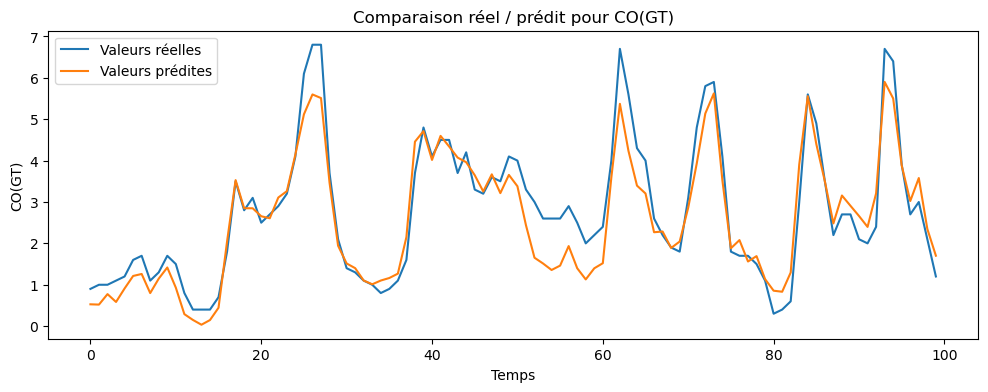

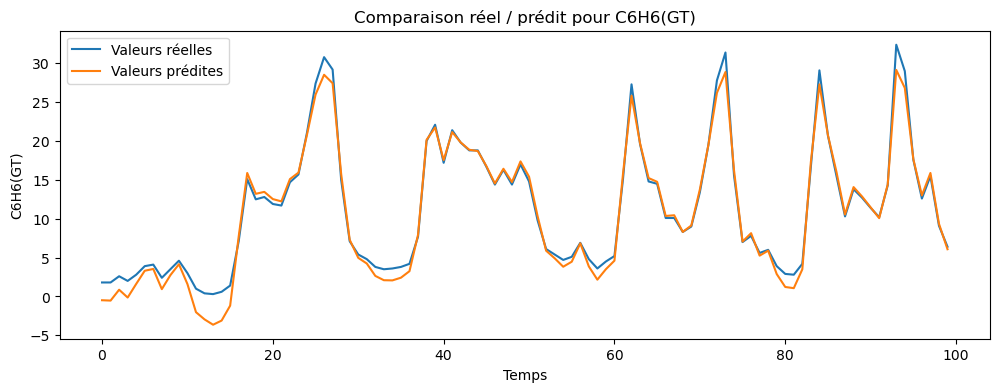

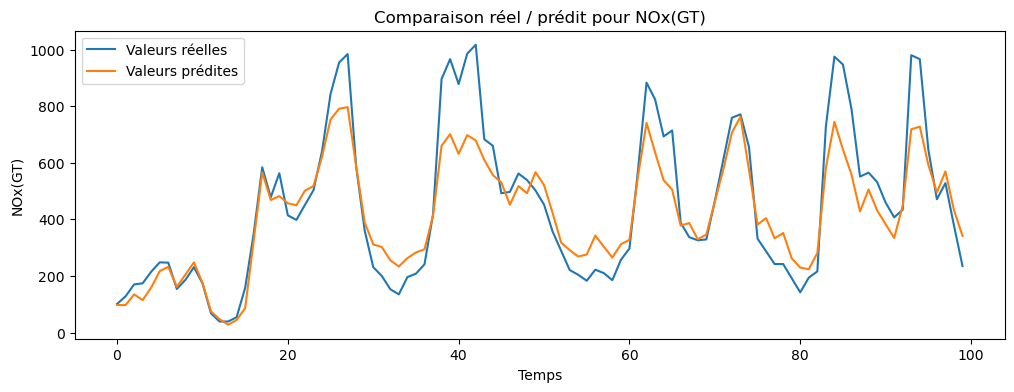

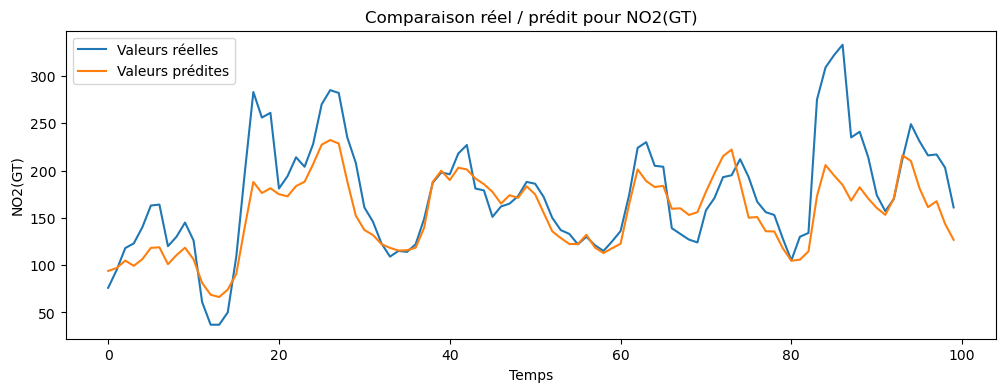

In [ ]:
for i, target in enumerate(targets):
    plt.figure(figsize=(12, 4))
    
    plt.plot(dates_test[:100],Y_test[target].values[:100], label="Valeurs réelles")
    plt.plot(dates_test[:100],Y_pred_reg[:100, i], label="Valeurs prédites")
    
    plt.title(f"Comparaison réel / prédit pour {target}")
    plt.xlabel("Temps")
    plt.ylabel(target)
    plt.legend()
    
    plt.show()

In [ ]:
mse_reg_test=mean_squared_error(Y_test.values,Y_pred_reg)
print("MSE global de la regression linéaire:",mse_reg_test)

rmse_par_variable = (mean_squared_error(Y_test.values,Y_pred_reg,multioutput='raw_values'))**0.5

print("RMSE par variable:", rmse_par_variable)

MSE global de la regression linéaire: 1840.362870886584
RMSE par variable: [ 0.48856098  1.50644567 77.67990917 36.39746042]


Le RMSE est à la même unité que les variables d'intérets, il est donc plus simple à interpréter que le MSE.

In [43]:
mean_y = Y_test[targets].mean().values
std_y = Y_test[targets].std().values

comparaison = pd.DataFrame({
    'Variable': targets,
    'mean': mean_y,
    'std': std_y,
    'RMSE': rmse_par_variable,
    'RMSE/mean': rmse_par_variable / mean_y,
    'RMSE/std': rmse_par_variable / std_y
})

print(comparaison)

   Variable        mean         std       RMSE  RMSE/mean  RMSE/std
0    CO(GT)    1.995392    1.308466   0.488561   0.244845  0.373385
1  C6H6(GT)    8.184521    6.305430   1.506446   0.184060  0.238912
2   NOx(GT)  304.459323  190.513777  77.679909   0.255141  0.407739
3   NO2(GT)  145.722102   51.585850  36.397460   0.249773  0.705571


L'erreur relative à la moyenne représente environs 20% de chaque variables, est l'erreur stantardisé est infèrieur à 1 pour chaque variable. On en conclu que la regression linéaire est un bon modèle.

On remarque que l'erreur du MSE est plus faible en prévision qu'en estimation, ce qui est innatendu. Nous allons vérifier si les données d'entrainement sont plus difficile à prédire que les données de test.

In [46]:

print("Écart-type sur Y_train \n", Y_train.std())
print("Écart-type sur Y_test \n",Y_test.std())

Écart-type sur Y_train 
 CO(GT)        1.468874
C6H6(GT)      7.614203
NOx(GT)     210.778646
NO2(GT)      42.838772
dtype: float64
Écart-type sur Y_test 
 CO(GT)        1.308466
C6H6(GT)      6.305430
NOx(GT)     190.513777
NO2(GT)      51.585850
dtype: float64


Il semble donc que l'estimation de `Y_train` a été perturbé par une plus grande variabilité des données d'entrainement pour `CO(GT)` , ` C6H6(GT)` et `NOx(GT)`.

Nous allons donc itérer le MSE pour differrents découpage du temps, nous utliserons `TimeSeriesSplit` au lieu de `train_test_split` pour respecter l'ordre chronologique.

In [ ]:
tscv = TimeSeriesSplit(n_splits=20)

mse_test = []
mse_train = []

for train_index, test_index in tscv.split(X):
    X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
    Y_tr, Y_te = Y.iloc[train_index], Y.iloc[test_index]

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    reg = linear_model.LinearRegression()
    reg.fit(X_tr, Y_tr)

    Y_pred = reg.predict(X_te)
    mse_test.append(mean_squared_error(Y_te, Y_pred))

    Y_estimated = reg.predict(X_tr)
    mse_train.append(mean_squared_error(Y_train, Y_estimated))


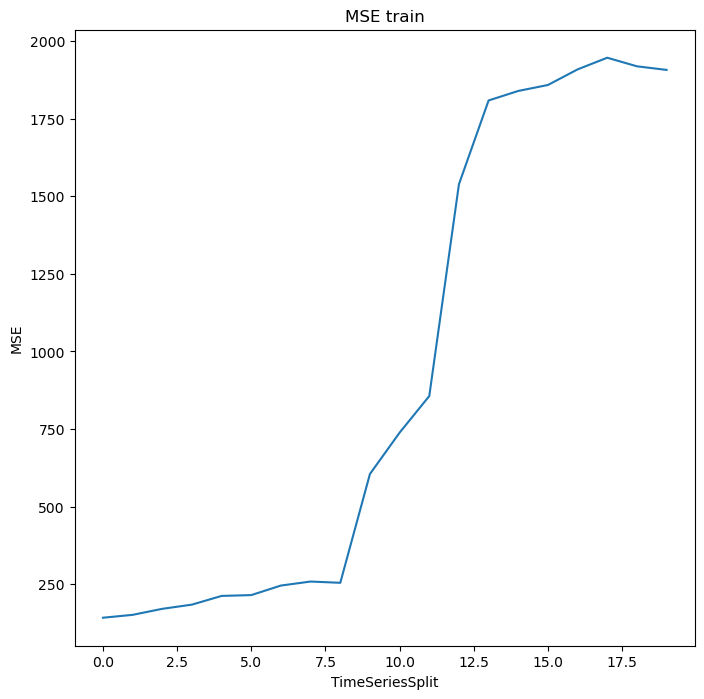

In [35]:
plt.figure(1,figsize=(8,8))
plt.title("MSE train")
plt.xlabel("TimeSeriesSplit")
plt.ylabel('MSE')
plt.plot(mse_train)

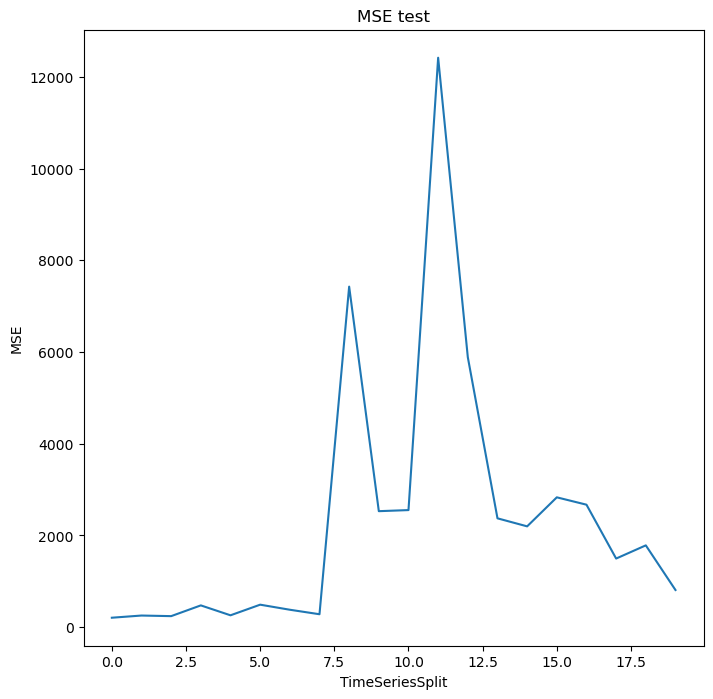

In [36]:
plt.figure(1,figsize=(8,8))
plt.title("MSE test")
plt.xlabel("TimeSeriesSplit")
plt.ylabel('MSE')
plt.plot(mse_test)

Le `mse_train` augmente à chaque nouvelle itération, ce qui suggère que plus les données d'entrainement sont importantes plus les anomalies sont importantes et donc moins le modèle est performant pour les estimer.

On remarque une hausse rapide du `mse_train` entre la 7ème et 12ème itération, ce qui coincide aussi avec les pics du `mse_test`. Pourtant les données de test ont toujours la même taille, cette augmentation est donc liée à la période temporelle concernée.

---

## Régréssion avec pénalisation Ridge

- Présentation de la méthode

Cette méthode consiste à résoudre le problème suivant ou $\alpha$ est un coeeficient de régularisation :

$$
\mathrm{argmin}_{\beta \in \mathbb{R}^d} ( \|Y - X\beta\|_2^2 + \alpha \|\beta\|_2^2)
$$

- Présentation du coefficient de regression $\alpha$

(à compléter...)

- Discussion sur l'influence de $\alpha$ sur les résultats

Nous allons comparer différrente valeurs de $\alpha$ pour différrentes puissance de $10$, en nous basant sur une moyenne du MSE de différent découpage temporel. En effet un coefficient meilleur pour un découpage en particulier ne l'est pas forcément pour un autre.

In [43]:
alphas = [0, 0.01, 0.1, 1, 10, 100]
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for alpha in alphas:
    mse_test = []

    for train_index, test_index in tscv.split(X):
        X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
        Y_tr, Y_te = Y.iloc[train_index], Y.iloc[test_index]

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        model = linear_model.Ridge(alpha=alpha)
        model.fit(X_tr, Y_tr)

        Y_pred = model.predict(X_te)

        mse_test.append(mean_squared_error(Y_te, Y_pred))

    results[alpha] = np.mean(mse_test)

print(results)

{0: np.float64(3399.584362981854), 0.01: np.float64(3399.687558227227), 0.1: np.float64(3400.6163757387258), 1: np.float64(3409.9073579187802), 10: np.float64(3501.59468259768), 100: np.float64(4182.964582722722)}


Le MSE augmente en fonction de $\alpha$ et le meilleur coefficient est 0, ce qui correspond à une régression sans pénalisation Ridge.  Donc la régularisation Ridge pour $\alpha>0$ n'a pas d'intéret. 


- Discussion sur les choix d'implémentation

(à compléter...)

---

# Méthode noyau

In [ ]:
alphas = [0.01, 0.1, 1]
gammas = [0.001, 0.01, 0.1]

tscv = TimeSeriesSplit(n_splits=3) #trop lent avec 5 folds, 
results_grid = {}

for alpha in alphas:
    for gamma in gammas:
        mse_folds = []
        for train_idx, test_idx in tscv.split(X):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            Y_tr, Y_te = Y.iloc[train_idx], Y.iloc[test_idx]

            sc_cv = StandardScaler()
            X_tr = sc_cv.fit_transform(X_tr)
            X_te = sc_cv.transform(X_te)

            m = KernelRidge(kernel='rbf', alpha=alpha, gamma=gamma)
            m.fit(X_tr, Y_tr)
            mse_folds.append(mean_squared_error(Y_te, m.predict(X_te)))

        results_grid[(alpha, gamma)] = np.mean(mse_folds)

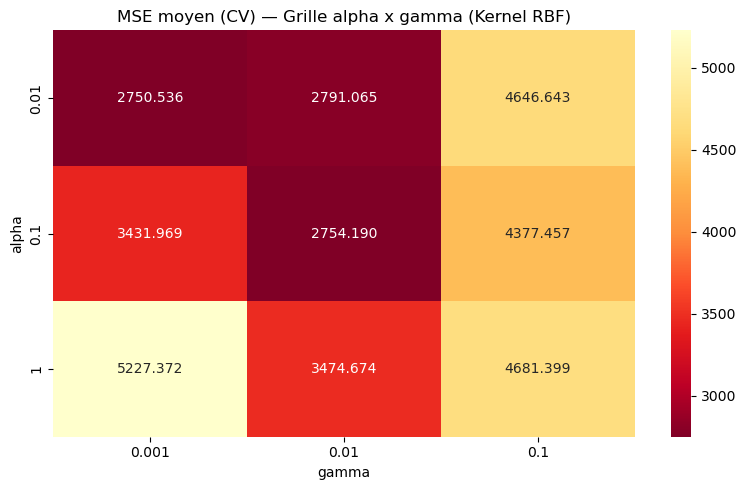

Meilleurs paramètres : alpha=0.01, gamma=0.001
MSE moyen correspondant : 2750.5356


In [47]:

# Affichage sous forme de heatmap
grid_matrix = np.array([[results_grid[(a, g)] for g in gammas] for a in alphas])

plt.figure(figsize=(8, 5))
sns.heatmap(
    grid_matrix,
    xticklabels=gammas,
    yticklabels=alphas,
    annot=True, fmt='.3f',
    cmap='YlOrRd_r'
)
plt.xlabel('gamma')
plt.ylabel('alpha')
plt.title('MSE moyen (CV) — Grille alpha x gamma (Kernel RBF)')
plt.tight_layout()
plt.show()

best_params = min(results_grid, key=results_grid.get)
best_alpha, best_gamma = best_params
print(f"Meilleurs paramètres : alpha={best_alpha}, gamma={best_gamma}")
print(f"MSE moyen correspondant : {results_grid[best_params]:.4f}")

In [51]:
#performance en prévision
model_best = KernelRidge(kernel='rbf', alpha=best_alpha, gamma=best_gamma)

model_best.fit(X_train, Y_train)
Y_pred_best = model_best.predict(X_test)

mse_final  = mean_squared_error(Y_test, Y_pred_best)
rmse_final = mean_squared_error(Y_test, Y_pred_best, multioutput='raw_values') ** 0.5

print(f"MSE global (alpha={best_alpha}, gamma={best_gamma}) : {mse_final:.4f}")
print(f"RMSE par variable : {rmse_final}")

MSE global (alpha=0.01, gamma=0.001) : 565.0479
RMSE par variable : [ 0.42522044  0.36562439 43.61027522 18.92144278]


In [52]:

# Tableau final
comparaison_final = pd.DataFrame({
    'Variable':  targets,
    'mean':      Y_test[targets].mean().values,
    'std':       Y_test[targets].std().values,
    'RMSE':      rmse_final,
    'RMSE/mean': rmse_final / Y_test[targets].mean().values,
    'RMSE/std':  rmse_final / Y_test[targets].std().values
})
print(comparaison_final.to_string(index=False))

Variable       mean        std      RMSE  RMSE/mean  RMSE/std
  CO(GT)   1.887879   1.306741  0.425220   0.225237  0.325405
C6H6(GT)   8.174545   6.726192  0.365624   0.044727  0.054358
 NOx(GT) 261.760606 166.045038 43.610275   0.166604  0.262641
 NO2(GT) 118.266667  38.978154 18.921443   0.159990  0.485437


---

# Réseau de neurones

$\mathrm{argmin}_{\theta \in \mathbb{R}^d}{\ell_n(\theta) + \lambda \mathrm{pen}(\theta)}$